In [4]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# creating a class "Value" which defines a data object suited to constructing neural networks & performing RL
class Value:

    def __init__(self, _data, _children=(), _op='', _label='', _grad=0.0):
        self._data = _data
        self._grad = _grad
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self._label = _label

    def __repr__(self):
        return f"Value(_data={self._data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self._data) + (other._data), (self, other), '+')

        # requires += for accumulation to handle redundant inputs
        def _backward():
            self._grad += out._grad
            other._grad += out._grad
            
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self._data) * (other._data), (self, other), '*')
        
        def _backward():
            self._grad += other._data*out._grad
            other._grad += self._data*out._grad
            
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self*other

    def __truediv__(self, other):
        return self * other**-1

    def relu(self):
        out = Value(0 if self._data < 0 else self._data, (self,), 'ReLU')

        def _backward():
            self._grad += (out._data > 0) * out._grad # gradient = 1 if data > 0 else 0
        
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self._data
        t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self._grad += (1 - t**2) * out._grad
            
        out._backward = _backward
        return out

    def exp(self):
        x = self._data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self._grad += out._data * out._grad
            
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "exponent must be integer or float."
        out = Value(self._data**other, (self, ), f'**{other}')

        def _backward():
            self._grad += other * self._data**(other-1) * out._grad

        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self._grad = 1.0
        
        for node in reversed(topo):
            node._backward()


In [9]:
# demonstrate linear equations of Values 

a = Value(2.0, _label='a')
b = Value(-3.0, _label='b')
c = a*b; c._label = 'c'
d = Value(10.0, _label='d')
e = c+d; e._label = 'e'
f = Value(-2.0, _label='f')
L = e*f; L._label='L'

In [6]:
from graphviz import Digraph
# visualize network with graphviz

def trace(root):
    # builds graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # create a rectangular "record" node for all Values in the graph
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n._label, n._data, n._grad), shape='record')
        
        if n._op:
            # if current Value is a result of an operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            # connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)

    return dot

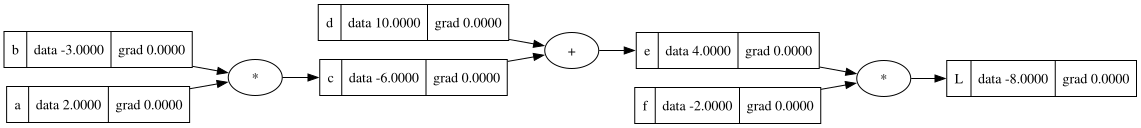

In [11]:
# print the network representation of the linear expression (a*b + d)*f = L
draw_dot(L)

gradient of added nodes:

df/dx = f(x+h) - f(x) / h

e = d+f
de/dd = (d+f+h) - d+f / h
h / h
1

gradient of multiplied nodes:

df(x)/dx = f(x+h) - f(x) / h

L = d*f
dL/dd = (d+h)*f - d*f / h
df + hf - df /h
hf/h
h

In [12]:
# manual backpropagation
L._grad = 1.0
f._grad = 4.0
e._grad = -2.0
d._grad = -2.0
c._grad = -2.0
b._grad = -4.0
a._grad = 6.0

In [13]:
# checking gradients numericaly 

def foo():
    h = 0.0001
    
    a = Value(2.0, _label='a')
    b = Value(-3.0, _label='b')
    d = Value(10.0, _label='d')
    c = a*b; c._label = 'c'
    e = c+d; e._label = 'e'
    f = Value(-2.0, _label='f')
    L = e*f; L._label='L'
    L1 = L

    a = Value(2.0, _label='a')
    b = Value(-3.0 + h, _label='b')
    d = Value(10.0, _label='d')
    c = a*b; c._label = 'c'
    e = c+d; e._label = 'e'
    e._data = e._data
    f = Value(-2.0, _label='f')
    L = e*f; L._label='L'
    L2 = L

    print((L2._data-L1._data)/h)

foo()

-4.000000000008441


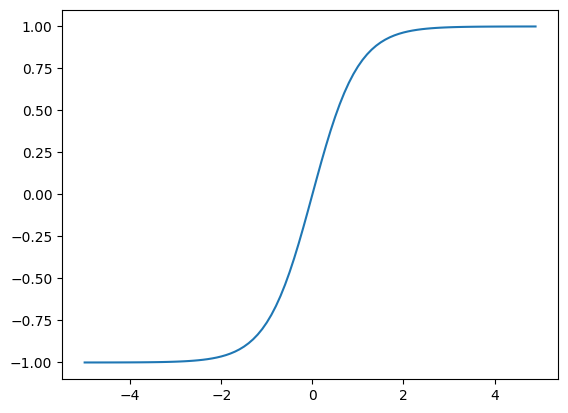

In [14]:
# activation function: tanh
plt.plot(np.arange(-5,5,0.1), np.tanh(np.arange(-5,5,0.1)))

In [15]:
# define a new node graph which mirrors a basic neural network function tanh(sum(X_i*W_i) + b_i) = activation_i

x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
b = Value(6.8813735870165432, _label='b')
x1w1 = x1*w1; x1w1._label='x1w1'
x2w2 = x2*w2; x2w2._label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label='x1w1 + x2w2'
n = x1w1x2w2 + b; n._label = 'n'
o = n.tanh(); o._label='o'

In [16]:
# manual backpropagation

o._grad = 1.0
# do/dn = 1 - o^2
n._grad = o._data**2
b._grad = 0.5
x1w1x2w2._grad = 0.5
x1w1._grad = 0.5
x2w2._grad = 0.5
x1._grad = w1._data*x1w1._grad
w1._grad = x1._data*x1w1._grad
x2._grad = w2._data*x2w2._grad
w2._grad = x2._data*x2w2._grad

In [17]:
# backpropagation through the _backward method, manually executed

o._grad = 1.0
o._backward()
n._backward()
b._backward() # no effect
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [18]:
# backpropagate using Class method

o.backward()

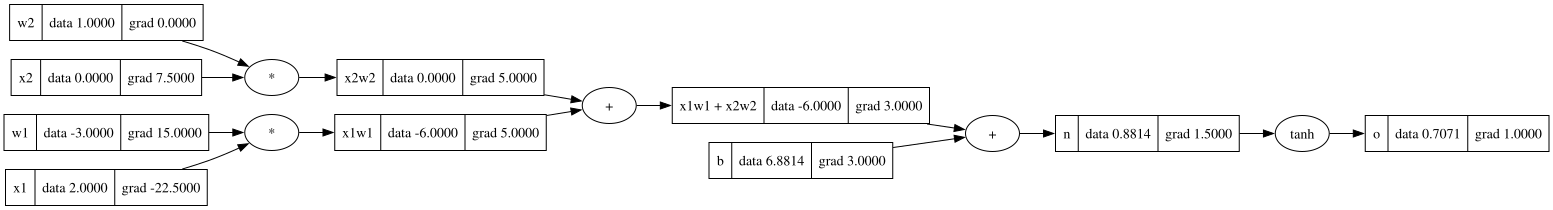

In [19]:
# print graph
draw_dot(o)

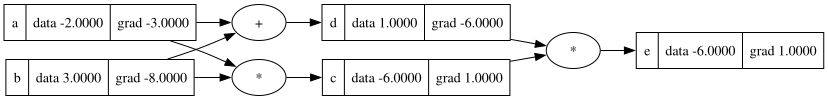

In [20]:
# network which requires accumulation, motivate the modifications to Value class for handling left handed addition/multiplication

a = Value(-2.0, _label='a')
b = Value(3.0, _label='b')
c = a*b; c._label='c'
d = a+b; d._label='d'
e = c*d; e._label='e'

e.backward()

draw_dot(e)

In [21]:
# define node graph with atomic tanh

x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
b = Value(6.8813735870165432, _label='b')
x1w1 = x1*w1; x1w1._label='x1w1'
x2w2 = x2*w2; x2w2._label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label='x1w1 + x2w2'
n = x1w1x2w2 + b; n._label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1)
o._label='o'
o.backward()

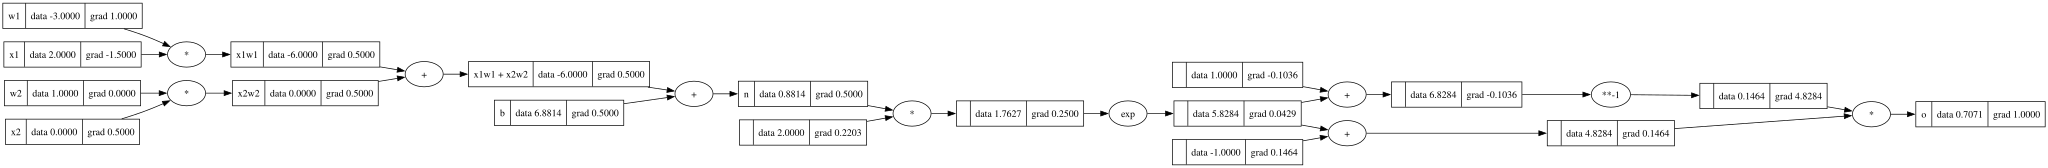

In [22]:
draw_dot(o)

In [23]:
import torch

In [24]:
# define same node graph with pytorch to demonstrate similarity with Value API

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870165432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0


In [7]:
# building classes to handle MLP
class Neuron:

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.tanh() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]
    
    def __call__(self, x):        
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

    def zero_grad(self):
        for layer in self.layers:
            for neuron in layer.parameters():
                neuron._grad = 0.0

In [8]:
x = [2.0, 3.0, -1.0] # example input vector

n = MLP(3, [4,4,1]) # define MLP: 3-4-4-1

n(x) # output of the MLP

Value(_data=0.3627890530693416)

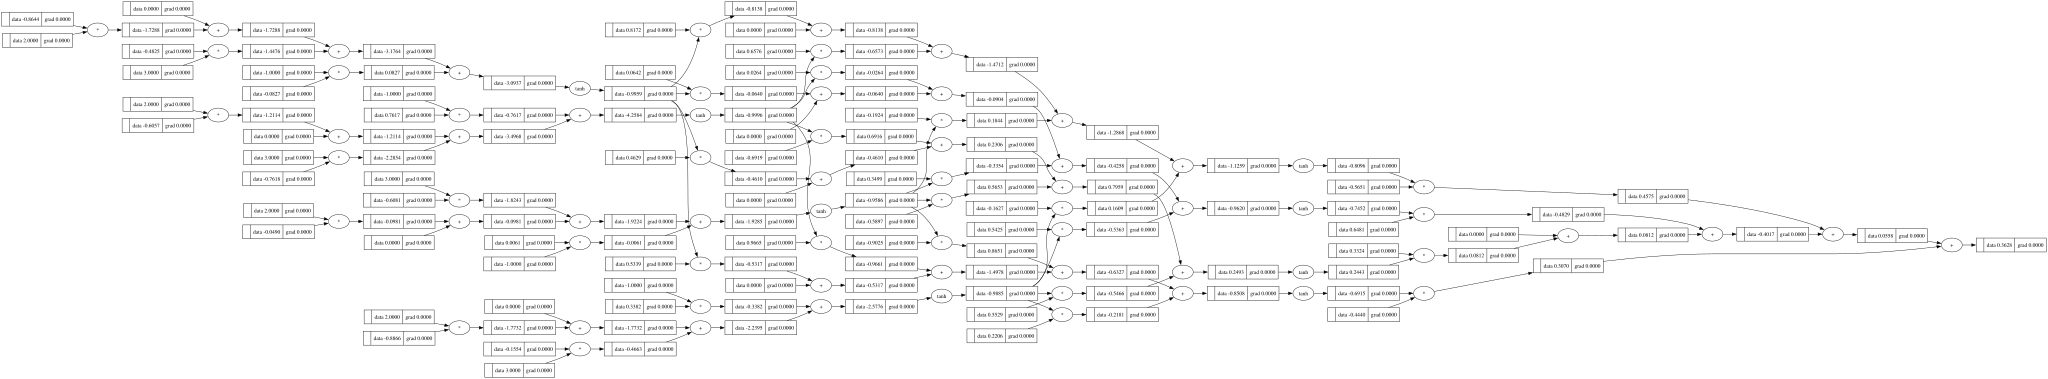

In [9]:
draw_dot(n(x)) # prints the entire 3,4,4,1 MLP

In [10]:
# training example

n = MLP(3, [4,4,1]) # define MLP: 3-4-4-1

training_inputs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]]

training_outputs = [1.0, -1.0, -1.0, 1.0]

In [11]:
# calculating loss of the neural network (forward pass)
predictions = [n(x) for x in training_inputs]
loss = 0

print("loss = sum of (predicted-actual)^2 over all training examples")
print("n = MLP(3, [4,4,1])\n")
for i in range(1,len(training_inputs)):
    MSE = (predictions[i] - training_outputs[i])**2
    print(f"n({training_inputs[i]}) = {round(predictions[i]._data, 4)} | actual value = {training_outputs[i]} | MSE = {round(MSE._data, 4)}")
    loss += MSE
print(f"\nloss = {round(loss._data, 4)}")


loss = sum of (predicted-actual)^2 over all training examples
n = MLP(3, [4,4,1])

n([3.0, -1.0, 0.5]) = -0.1383 | actual value = -1.0 | MSE = 0.7425
n([0.5, 1.0, 1.0]) = 0.8476 | actual value = -1.0 | MSE = 3.4136
n([1.0, 1.0, -1.0]) = -0.7506 | actual value = 1.0 | MSE = 3.0645

loss = 7.2206


In [12]:
# calculate gradients wrt loss
loss.backward()

In [13]:
# parameters of a single neuron in the network (gradient determined by .backward())
print(n.layers[0].neurons[0].w[0]._data)
print(n.layers[0].neurons[0].w[0]._grad)

-0.04692810584724283
2.715571340798987


In [14]:
# nudge values by gradient
for p in n.parameters():
    p._data += -0.01*p._grad

In [15]:
# the neuron value has changed according to gradient to minimize loss
print(n.layers[0].neurons[0].w[0]._data)

-0.07408381925523269


In [16]:
# gradient descent = forward pass, backpropogation, nudge parameters

learning_rate = 0.05

for k in range(20):    
    # forward pass - calculate loss
    predictions = [n(x) for x in training_inputs]
    loss = sum((pred - true)**2 for pred, true in zip(predictions, training_outputs))

    # reverse pass - calculate gradient wrt loss
    for p in n.parameters():
        p._grad = 0.0
    loss.backward()

    # update parameters by gradient
    for p in n.parameters():
        p._data += -learning_rate * p._grad

    print(f"step {k}: loss = {loss._data}")

step 0: loss = 6.954177427448856
step 1: loss = 3.5599070028483233
step 2: loss = 1.1493784154629145
step 3: loss = 0.4341218475263388
step 4: loss = 0.19174792247310418
step 5: loss = 0.09510822410610154
step 6: loss = 0.056171624402192
step 7: loss = 0.04023035687554502
step 8: loss = 0.03318111732256042
step 9: loss = 0.029534920651869606
step 10: loss = 0.02721830232694057
step 11: loss = 0.02545918765000079
step 12: loss = 0.02396858790348806
step 13: loss = 0.02263458207233448
step 14: loss = 0.021410220244075566
step 15: loss = 0.02027283971700059
step 16: loss = 0.01920929174337331
step 17: loss = 0.01821051608131051
step 18: loss = 0.017269491704226904
step 19: loss = 0.01638041690761345


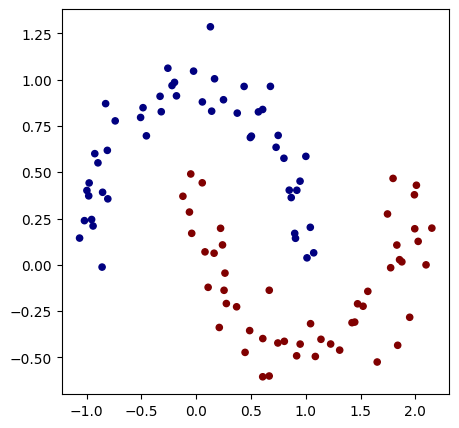

In [20]:
# contrive a slightly harder dataset to learn
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.12)
y = y*2 - 1 # make y be -1 or 1

# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [23]:
# define MLP - 2 layers, input an x-y coordinate, return single value
model = MLP(2,[16,16,1])

In [24]:
# loss function
def loss():
    
    # forward the model to get scores
    training_input, training_output = X, y
    inputs = [list(map(Value, coordinates)) for coordinates in training_input]
    scores = list(map(model, inputs))
    
    # Hinge loss (Max Margin)
    losses = [(1 + (-y * score)).relu() for y, score in zip(training_output, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    
    # L2 regularization - discourages extreme weights
    lamda = 1e-4
    l2_loss = lamda * sum((p*p for p in model.parameters()))
    
    total_loss = data_loss + l2_loss
    
    # get accuracy of the model
    accuracy = [(y > 0) == (score._data > 0) for y, score in zip(training_output, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(f"loss = {round(total_loss._data, 4)}, acc = {acc:%}")

loss = 2.144, acc = 14.000000%


In [25]:
# optimization
for k in range(20):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update
    learning_rate = 1.0 
    for p in model.parameters():
        p._data -= learning_rate * p._grad
    
    print(f"step {k} | loss {total_loss._data} | accuracy {acc*100}%")

step 0 | loss 2.1440186479364303 | accuracy 14.000000000000002%
step 1 | loss 0.9124285216458194 | accuracy 77.0%
step 2 | loss 0.4620164944991135 | accuracy 87.0%
step 3 | loss 0.4706799780189967 | accuracy 83.0%
step 4 | loss 0.41342477130687244 | accuracy 87.0%
step 5 | loss 0.7380377890550561 | accuracy 80.0%
step 6 | loss 0.3339890823917563 | accuracy 88.0%
step 7 | loss 0.33734324722860426 | accuracy 86.0%
step 8 | loss 0.30656249491977156 | accuracy 88.0%
step 9 | loss 0.5915748306665137 | accuracy 83.0%
step 10 | loss 0.3290034462164097 | accuracy 89.0%
step 11 | loss 0.4400622314428203 | accuracy 88.0%
step 12 | loss 0.2272691135435128 | accuracy 92.0%
step 13 | loss 0.2194957093393584 | accuracy 92.0%
step 14 | loss 0.2643401660747544 | accuracy 91.0%
step 15 | loss 0.5348564957915278 | accuracy 85.0%
step 16 | loss 0.3012670903023551 | accuracy 89.0%
step 17 | loss 0.4608920267980031 | accuracy 88.0%
step 18 | loss 0.15459489825254707 | accuracy 92.0%
step 19 | loss 0.121433

(-1.604438435179041, 2.195561564820962)

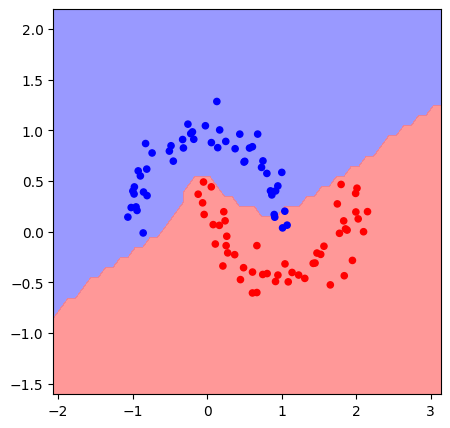

In [26]:
# visualize decision boundary
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s._data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, cmap=plt.cm.bwr, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.bwr)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

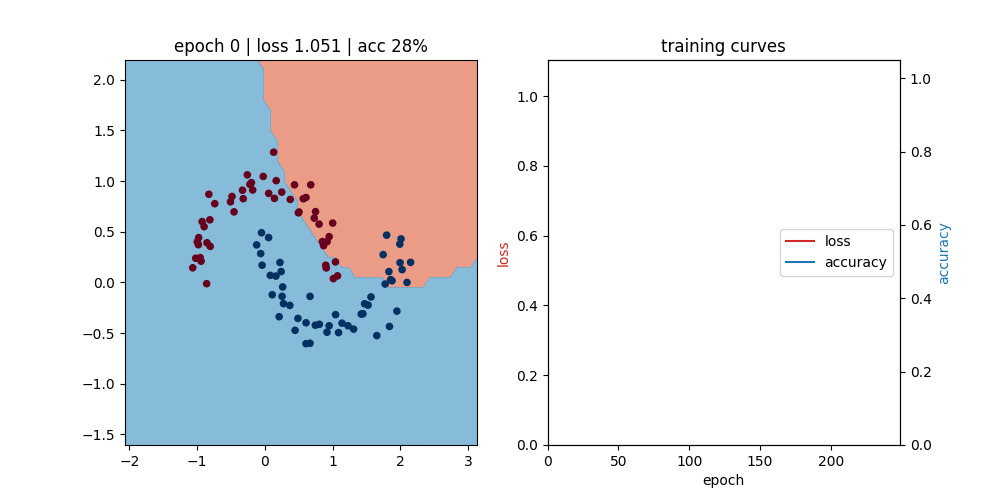

In [27]:
# animating the training

import torch
from matplotlib import animation
from IPython.display import Image

# using PyTorch for speed
Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

# same architecture as the micrograd MLP: 2 -> 16 -> 16 -> 1
torch.manual_seed(0)
model = torch.nn.Sequential(
  torch.nn.Linear(2, 16),  torch.nn.Tanh(),
  torch.nn.Linear(16, 16), torch.nn.Tanh(),
  torch.nn.Linear(16, 1),
)

# meshgrid for the boundary
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
mesh = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

def decision_grid():
  with torch.no_grad():
      return (model(mesh).squeeze() > 0).numpy().reshape(xx.shape)

opt = torch.optim.SGD(model.parameters(), lr=0.2)

epochs, frames = 250, []
for k in range(epochs):
  scores = model(Xt).squeeze()
  data_loss = torch.clamp(1 - yt * scores, min=0).mean()
  l2 = 1e-4 * sum((p ** 2).sum() for p in model.parameters())
  loss = data_loss + l2

  opt.zero_grad()
  loss.backward() 
  opt.step()

  acc = ((scores > 0) == (yt > 0)).float().mean().item()
  frames.append((decision_grid(), loss.item(), acc))

# pull the recorded series out of frames
losses   = [f[1] for f in frames]
accs     = [f[2] for f in frames]
epochs_x = list(range(len(frames)))

# side-by-side: boundary | training curves
fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=(10, 5))
ax_acc = ax_c.twinx()  # accuracy gets its own y-axis (different scale than loss)

# fix the curve axes up front so the lines draw in without the plot rescaling each frame
ax_c.set_xlim(0, len(frames) - 1)
ax_c.set_ylim(0, max(losses) * 1.05)
ax_acc.set_ylim(0, 1.05)
ax_c.set_xlabel('epoch')
ax_c.set_ylabel('loss', color='tab:red')
ax_acc.set_ylabel('accuracy', color='tab:blue')
ax_c.set_title('training curves')

# persistent line objects update each frame
(line_loss,) = ax_c.plot([], [], color='tab:red',  label='loss')
(line_acc,)  = ax_acc.plot([], [], color='tab:blue', label='accuracy')
ax_c.legend(handles=[line_loss, line_acc], loc='center right')

def draw(i): 
  # left: decision boundary
  ax_b.clear()
  Z, l, a = frames[i]
  ax_b.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
  ax_b.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.RdBu)
  ax_b.set_xlim(xx.min(), xx.max()); ax_b.set_ylim(yy.min(), yy.max())
  ax_b.set_title(f"epoch {i} | loss {l:.3f} | acc {a:.0%}")

  # right: extend the curves up to the current epoch
  line_loss.set_data(epochs_x[:i+1], losses[:i+1])
  line_acc.set_data(epochs_x[:i+1], accs[:i+1])

hold = 50   # 50 frames x 20ms = 1s pause
frame_seq = [0] * hold + list(range(len(frames))) + [len(frames) - 1] * hold
anim = animation.FuncAnimation(fig, draw, frame_seq, interval=20)
anim.save('decision_boundary.gif', writer='pillow')
plt.close(fig)
Image('decision_boundary.gif')